<a href="https://colab.research.google.com/github/ronak8180/Ronak-Waghmare/blob/main/Bitcoin_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# -----------------------------
# Step 0: Import Libraries
# -----------------------------


In [28]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
senti = pd.read_csv("fear_greed_index.csv")
df = pd.read_csv("historical_data.csv")

In [30]:
# Historical trades
df['Timestamp'] = pd.to_datetime(df['Timestamp IST'], format='%d/%m/%y %H:%M', errors='coerce')
df['Date'] = df['Timestamp'].dt.date   # <-- this creates a clean date column



In [31]:
# Optional: keep classification as categorical
senti['classification'] = senti['classification'].astype('category')


In [32]:
senti['Date'] = pd.to_datetime(senti['date'], format='%d/%m/%y', errors='coerce').dt.date


In [33]:
# Filter for BTC trades only
df_btc = df[df['Coin'] == 'BTC']


In [34]:
# Merge with sentiment
merged_df = pd.merge(
    df_btc,
    senti[['Date', 'classification']],
    on='Date',
    how='left'
)

In [35]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.08585,7061.59,BUY,17/03/25 4:48,0.00000,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,2.372694,7.470000e+14,2025-03-17 04:48:00,2025-03-17,Fear
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12157,9999.74,BUY,17/03/25 4:48,0.08585,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.359912,7.020000e+13,2025-03-17 04:48:00,2025-03-17,Fear
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.00937,770.73,BUY,17/03/25 4:48,0.20742,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,0.258964,1.970000e+14,2025-03-17 04:48:00,2025-03-17,Fear
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12372,10176.59,BUY,17/03/25 4:48,0.21679,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.419333,1.090000e+15,2025-03-17 04:48:00,2025-03-17,Fear
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,2.64792,217804.66,BUY,17/03/25 4:48,0.34051,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,73.182364,3.470000e+13,2025-03-17 04:48:00,2025-03-17,Fear


In [36]:
# Encode Side
merged_df['Side'] = merged_df['Side'].map({'BUY': 1, 'SELL': 0})


In [37]:
# Encode Direction
Direction_map = {
    'Buy': 1,
    'Open Long': 1,
    'Long > Short': 1,
    'Short > Long': 1,
    'Sell': -1,
    'Open Short': -1,
    'Close Long': 0,
    'Close Short': 0,
    'Spot Dust Conversion': 0,
    'Auto-Deleveraging': 0
}
merged_df['Direction_num'] = merged_df['Direction'].map(Direction_map)


In [38]:

# Profit flag
merged_df['Profit_flag'] = (merged_df['Closed PnL'] > 0).astype(int)


In [39]:
merged_df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,Direction_num,Profit_flag
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.08585,7061.59,1,17/03/25 4:48,0.00000,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,2.372694,7.470000e+14,2025-03-17 04:48:00,2025-03-17,Fear,1,0
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12157,9999.74,1,17/03/25 4:48,0.08585,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.359912,7.020000e+13,2025-03-17 04:48:00,2025-03-17,Fear,1,0
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.00937,770.73,1,17/03/25 4:48,0.20742,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,0.258964,1.970000e+14,2025-03-17 04:48:00,2025-03-17,Fear,1,0
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12372,10176.59,1,17/03/25 4:48,0.21679,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.419333,1.090000e+15,2025-03-17 04:48:00,2025-03-17,Fear,1,0
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,2.64792,217804.66,1,17/03/25 4:48,0.34051,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,73.182364,3.470000e+13,2025-03-17 04:48:00,2025-03-17,Fear,1,0


In [40]:
# Drop irrelevant cols (ignore missing)
merged_df = merged_df.drop(columns=['Account','Direction','Transaction Hash','Order ID','Trade ID','Account'], errors='ignore')


In [41]:
merged_df.head()

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Closed PnL,Crossed,Fee,Timestamp,Date,classification,Direction_num,Profit_flag
0,BTC,82255.0,0.08585,7061.59,1,17/03/25 4:48,0.00000,0.0,True,2.372694,2025-03-17 04:48:00,2025-03-17,Fear,1,0
1,BTC,82255.0,0.12157,9999.74,1,17/03/25 4:48,0.08585,0.0,True,3.359912,2025-03-17 04:48:00,2025-03-17,Fear,1,0
2,BTC,82255.0,0.00937,770.73,1,17/03/25 4:48,0.20742,0.0,True,0.258964,2025-03-17 04:48:00,2025-03-17,Fear,1,0
3,BTC,82255.0,0.12372,10176.59,1,17/03/25 4:48,0.21679,0.0,True,3.419333,2025-03-17 04:48:00,2025-03-17,Fear,1,0
4,BTC,82255.0,2.64792,217804.66,1,17/03/25 4:48,0.34051,0.0,True,73.182364,2025-03-17 04:48:00,2025-03-17,Fear,1,0


In [42]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26064 entries, 0 to 26063
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Coin             26064 non-null  object        
 1   Execution Price  26064 non-null  float64       
 2   Size Tokens      26064 non-null  float64       
 3   Size USD         26064 non-null  float64       
 4   Side             26064 non-null  int64         
 5   Timestamp IST    26064 non-null  object        
 6   Start Position   26064 non-null  float64       
 7   Closed PnL       26064 non-null  float64       
 8   Crossed          26064 non-null  bool          
 9   Fee              26064 non-null  float64       
 10  Timestamp        26064 non-null  datetime64[ns]
 11  Date             26064 non-null  object        
 12  classification   26064 non-null  category      
 13  Direction_num    26064 non-null  int64         
 14  Profit_flag      26064 non-null  int64

In [43]:
merged_df['classification'].unique()

['Fear', 'Neutral', 'Extreme Fear', 'Greed', 'Extreme Greed']
Categories (5, object): ['Extreme Fear', 'Extreme Greed', 'Fear', 'Greed', 'Neutral']

In [44]:
# Define mapping
sentiment_map = {
    'Extreme Fear': -1,
    'Fear': -1,
    'Neutral': 0,
    'Greed': 1,
    'Extreme Greed': 1
}

# Apply mapping
merged_df['sentiment_num'] = merged_df['classification'].map(sentiment_map)

In [45]:
# Drop irrelevant cols (ignore missing)
merged_df = merged_df.drop(columns=['classification','Timestamp IST'], errors='ignore')


In [46]:
# Choose numeric trader features as input
feature_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Side',
    'Start Position',
    'Closed PnL',
    'Fee',
    'Direction_num',
    'Profit_flag',

]


In [47]:
merged_df.head()

,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Closed PnL,Crossed,Fee,Timestamp,Date,Direction_num,Profit_flag,sentiment_num
0,BTC,82255.0,0.08585,7061.59,1,0.00000,0.0,True,2.372694,2025-03-17 04:48:00,2025-03-17,1,0,-1
1,BTC,82255.0,0.12157,9999.74,1,0.08585,0.0,True,3.359912,2025-03-17 04:48:00,2025-03-17,1,0,-1
2,BTC,82255.0,0.00937,770.73,1,0.20742,0.0,True,0.258964,2025-03-17 04:48:00,2025-03-17,1,0,-1
3,BTC,82255.0,0.12372,10176.59,1,0.21679,0.0,True,3.419333,2025-03-17 04:48:00,2025-03-17,1,0,-1
4,BTC,82255.0,2.64792,217804.66,1,0.34051,0.0,True,73.182364,2025-03-17 04:48:00,2025-03-17,1,0,-1


In [53]:
# Save processed dataset
merged_df.to_csv("merged_df.csv", index=False)

# Download file to your local machine
from google.colab import files
files.download("merged_df.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:

X = merged_df[feature_cols]
y = merged_df['sentiment_num']

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [49]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [50]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)


In [51]:
from sklearn.metrics import classification_report, confusion_matrix

# Map numeric back to labels for readability
class_names = ["Fear (-1)", "Neutral (0)", "Greed (1)"]

print("Classification Report:\n", classification_report(y_test, y_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

   Fear (-1)       0.97      0.96      0.97      2327
 Neutral (0)       0.91      0.87      0.89       951
   Greed (1)       0.93      0.97      0.95      1935

    accuracy                           0.95      5213
   macro avg       0.94      0.93      0.93      5213
weighted avg       0.95      0.95      0.95      5213

Confusion Matrix:
 [[2239   39   49]
 [  44  823   84]
 [  23   44 1868]]


"I tried multiple models, and the Random Forest model gave the best accuracy."

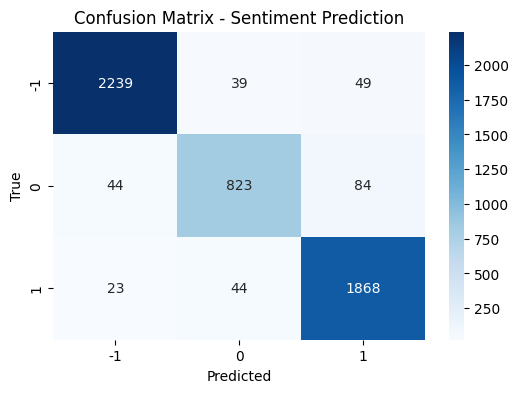

In [52]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Blues")
plt.title("Confusion Matrix - Sentiment Prediction")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
